In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import os

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

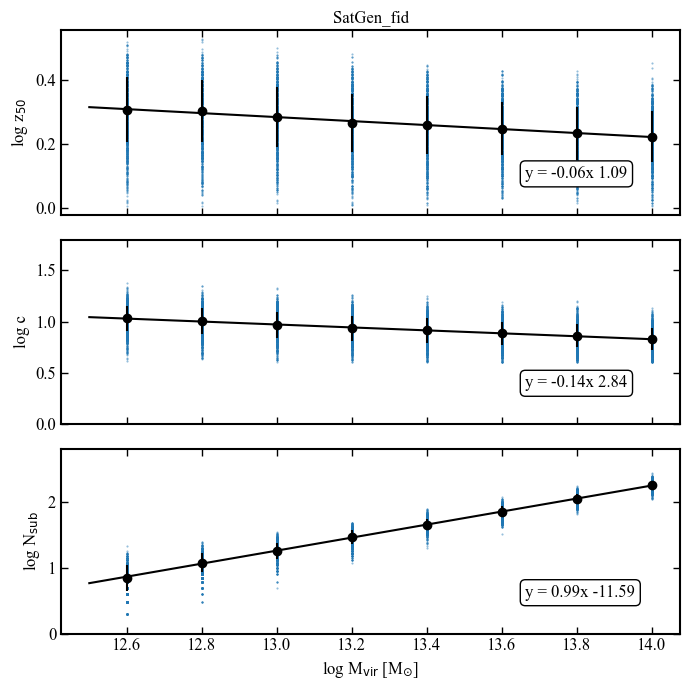

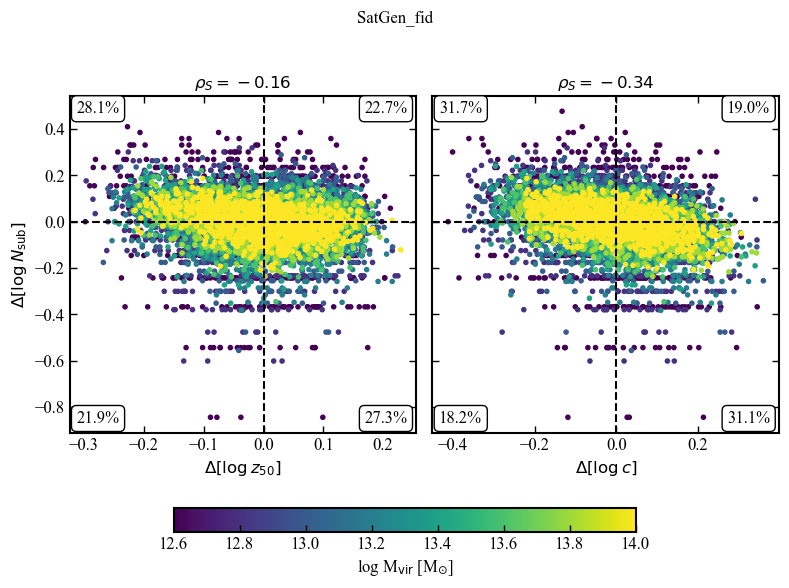

In [4]:
fid = jsm_ancillary.load_massspec("../../data/fid/", "artificial", 0)

satgen_high_mass = fid[fid["logMvir"] > 12.5]
satgen_high_mass = satgen_high_mass.sort_values("logMvir")

norm = jsm_stats.CorrNorm_satgen(satgen_high_mass, dataset_title="SatGen_fid")
norm.write_summary_tab(filepath= "../../data/summary_tabs/")

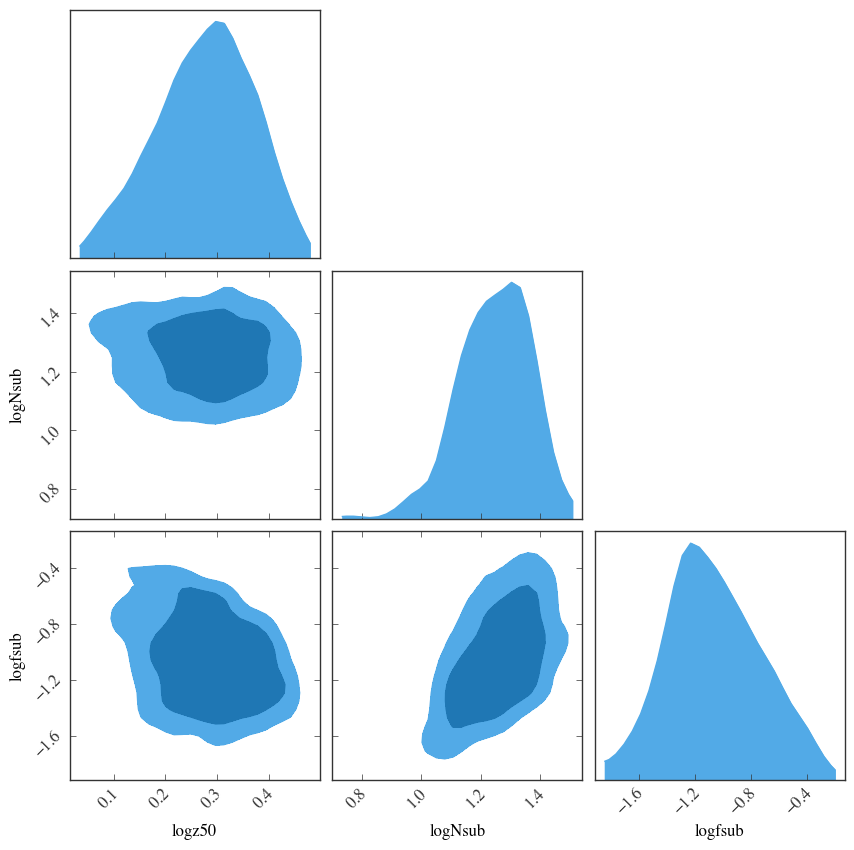

In [13]:
sub13 = norm.df[(norm.df["logMvir"] >= 12.9) & (norm.df["logMvir"] < 13.1)]
small = sub13[["logz50", "logNsub", "logfsub"]]

import pygtc
corner_comp = pygtc.plotGTC(
    chains=small,
    smoothingKernel=1.4,
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose',
    colorsOrder=["blues", "oranges"] 
)